# Лабораторная работа № 1.2
## Нормальное распределение

**Выполнила:** Якупова Нелли, Елдашов Владислав

**Группа:** БИВТ-24-АЭ-3

Исходные данные — возраст людей, совершивших преступления в Москве в 2021 году.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

file = next((candidate for candidate in [Path("ЛР-1.txt"), Path("data/ЛР-1.txt"), Path("../data/ЛР-1.txt")] if candidate.exists()), Path("ЛР-1.txt"))
if not file.exists():
    from google.colab import files
    uploaded = files.upload()
    file = Path(next(iter(uploaded)))
data = pd.read_table(file, header=None)[0]
N = len(data)
print("Количество наблюдений:", N)
print("Минимальный возраст:", data.min())
print("Максимальный возраст:", data.max())

Количество наблюдений: 32423
Минимальный возраст: 14
Максимальный возраст: 73

### 1. Асимметрия и эксцесс

In [2]:
def asymmetry(x, mean, sigma):
    return (((x-mean)**3).sum()/len(x))/sigma**3

def excess(x, mean, sigma):
    return (((x-mean)**4).sum()/len(x))/sigma**4 - 3

mean = data.mean()
D = ((data-mean)**2).mean()
sigma = D**0.5
As = asymmetry(data, mean, sigma)
Ek = excess(data, mean, sigma)
print(f"Средняя: {mean:.3f}")
print(f"Дисперсия: {D:.3f}")
print(f"Среднее квадратическое отклонение: {sigma:.3f}")
print(f"Асимметрия: {As:.4f}")
print(f"Эксцесс: {Ek:.4f}")

Средняя: 35.373
Дисперсия: 144.917
Среднее квадратическое отклонение: 12.038
Асимметрия: 0.6225
Эксцесс: -0.0602

Асимметрия положительная (`As = 0.623`), значит распределение имеет правый перекос. Эксцесс близок к нулю (`Ek = -0.060`).

### 2. Проверка правила трёх сигм

In [3]:
expected = {1: 0.683, 2: 0.954, 3: 0.997}
rows = []
for k in (1, 2, 3):
    left = mean-k*sigma
    right = mean+k*sigma
    count = ((data >= left) & (data <= right)).sum()
    rows.append({
        "Интервал": f"±{k}σ",
        "Границы": f"[{left:.2f}; {right:.2f}]",
        "Число наблюдений": count,
        "Фактическая доля": count/N,
        "Теоретическая доля": expected[k]
    })
sigma_table = pd.DataFrame(rows)
sigma_table

Интервал | Границы | Число наблюдений | Фактическая доля | Теоретическая доля
±1σ | [23.33; 47.41] | 21513 | 66.35% | 68.3%
±2σ | [11.30; 59.45] | 30695 | 94.67% | 95.4%
±3σ | [-0.74; 71.49] | 32406 | 99.95% | 99.7%

В интервалах `±σ`, `±2σ` и `±3σ` находится соответственно **66.35%**, **94.67%** и **99.95%** наблюдений. Значения близки к теоретическим 68,3%, 95,4% и 99,7%. Правило трёх сигм выполняется приблизительно. Положительная асимметрия показывает, что распределение не является идеально симметричным.

### 3. Статистическая функция распределения

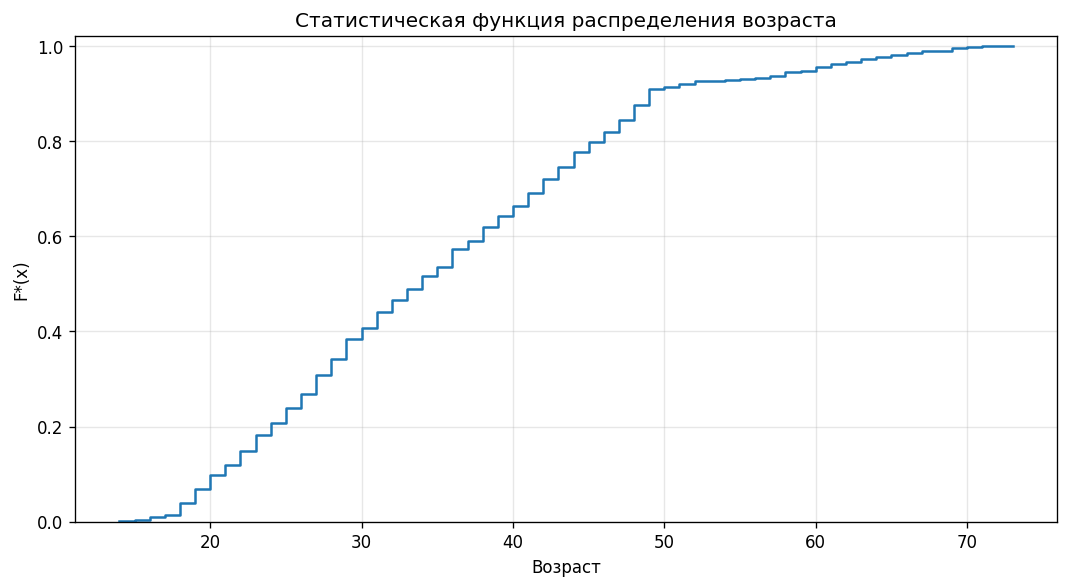

In [4]:
discrete = data.value_counts().sort_index()
F = discrete.cumsum()/N

plt.figure(figsize=(9,5))
plt.step(F.index, F.values, where="post")
plt.title("Статистическая функция распределения возраста")
plt.xlabel("Возраст")
plt.ylabel("F*(x)")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.show()

### Вывод

Асимметрия выборки равна 0.6225, эксцесс — -0.0602. По правилу трёх сигм доли наблюдений близки к нормальному распределению, однако положительная асимметрия указывает на правый перекос. Построена статистическая функция распределения по накопленным частотам.